# CSCI 3360 Project 

## Instructions

In [47]:
#!pip install matplotlib numpy pandas 
import numpy
import math
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
# run below code once to install ARIMA
#!pip install sktime
from sktime.forecasting.arima import AutoARIMA
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.performance_metrics.forecasting import mean_absolute_error
import warnings
warnings.filterwarnings(
    "ignore", 
    message="'force_all_finite' was renamed to 'ensure_all_finite'"
)
from sklearn.metrics import mean_squared_error
#warnings.filterwarnings("ignore", category=FutureWarning)

## Academic Honesty Statement

In [2]:
first_name_one = "Fidel"
last_name_one  = "Arroyo"
first_name_two = "Sanjana"
last_name_two= "Arun"


print("****************************************************************")
print("CSCI 3360 Project")
print(f"completed by {first_name_one} {last_name_one} and  {first_name_two} {last_name_two}")
print(f"""
We, GROUP 11: {first_name_one} {last_name_one} and {first_name_two} {last_name_two}, certify that the following code
represents our own work. We have neither received nor given 
inappropriate assistance. We have not consulted with another
individual, other than a member of the teaching staff, regarding
the specifics of our project. We recognize that any 
unauthorized assistance or plagiarism will be handled in 
accordance with the University of Georgia's Academic Honesty
Policy and the policies of this course.
""")
print("****************************************************************")

****************************************************************
CSCI 3360 Project
completed by Fidel Arroyo and  Sanjana Arun

We, GROUP 11: Fidel Arroyo and Sanjana Arun, certify that the following code
represents our own work. We have neither received nor given 
inappropriate assistance. We have not consulted with another
individual, other than a member of the teaching staff, regarding
the specifics of our project. We recognize that any 
unauthorized assistance or plagiarism will be handled in 
accordance with the University of Georgia's Academic Honesty
Policy and the policies of this course.

****************************************************************


## Loading 

We will first load the data and have the orginal pd as wage_data.

In [52]:
wage_data = pd.read_csv('./median_average_wages.csv')
print(wage_data)

    year  median  average  men_median  men_average  women_median  \
0   2022   22.88    32.00       24.91        35.82         20.74   
1   2021   23.05    32.08       24.93        35.61         21.46   
2   2020   23.64    32.54       25.95        36.03         21.72   
3   2019   22.12    30.36       24.04        33.65         20.42   
4   2018   21.90    29.83       23.42        33.19         19.73   
5   2017   21.55    29.21       23.78        32.27         19.69   
6   2016   21.36    29.00       23.44        32.18         19.44   
7   2015   20.99    28.43       23.19        31.52         19.07   
8   2014   20.65    27.36       22.43        30.08         18.63   
9   2013   20.63    27.54       22.63        30.49         18.87   
10  2012   20.53    27.41       22.87        30.45         19.01   
11  2011   20.79    27.26       22.76        29.99         19.34   
12  2010   21.32    27.84       23.34        30.85         19.47   
13  2009   21.45    27.90       23.90        31.

In [4]:
print(f"Shape: {wage_data.shape}")
print(f"Rows: {wage_data.shape[0]}")
print(f"Columns: {wage_data.shape[1]}")

Shape: (50, 31)
Rows: 50
Columns: 31


In [5]:
group_dfs = []
group_train = []
group_test = []
year_df = wage_data["year"]
split = math.floor(year_df.shape[0] * 0.20)
year_test = year_df[:split]
year_train = year_df[split:]
print(f"Split year is {year_df[split]}, so we are testing for any year after {year_df[split]}")

Split year is 2012, so we are testing for any year after 2012


##  Exploratory Data Analysis

We will showcase our Exploratory Data analysis:  mean, minimum and maximum, and standard deviation for a training set (80%) split. We will also display the histograms for each categorical group.

In [6]:
i = 0;
for group in wage_data.columns:
    if (i > 0):
        temp_df = wage_data[group].dropna()
        test = temp_df[:split]
        train = temp_df[split:]
        trim = train.describe(include=numpy.number).loc[ ['mean', 'std', 'min', 'max', '50%'] ]
        print(f"Train {group}")
        print(trim)
        correlation = train.corr(year_train)
        print(f"Correlation between {group} and year: {correlation}")
        print()
        print()
        group_dfs.append(temp_df)
        group_train.append(train)
        group_test.append(test)
    i+=1

Train median
mean    19.857750
std      0.875075
min     18.780000
max     21.450000
50%     19.385000
Name: median, dtype: float64
Correlation between median and year: 0.7829267929893973


Train average
mean    24.497000
std      1.880201
min     22.420000
max     27.900000
50%     23.700000
Name: average, dtype: float64
Correlation between average and year: 0.9258716327106336


Train men_median
mean    23.083250
std      0.797619
min     21.510000
max     24.270000
50%     23.260000
Name: men_median, dtype: float64
Correlation between men_median and year: -0.296969590750943


Train men_average
mean    27.880750
std      1.599648
min     26.200000
max     31.150000
50%     26.990000
Name: men_average, dtype: float64
Correlation between men_average and year: 0.8324766914479996


Train women_median
mean    17.00050
std      1.56914
min     14.88000
max     19.57000
50%     16.75000
Name: women_median, dtype: float64
Correlation between women_median and year: 0.9764693117738396


Train w

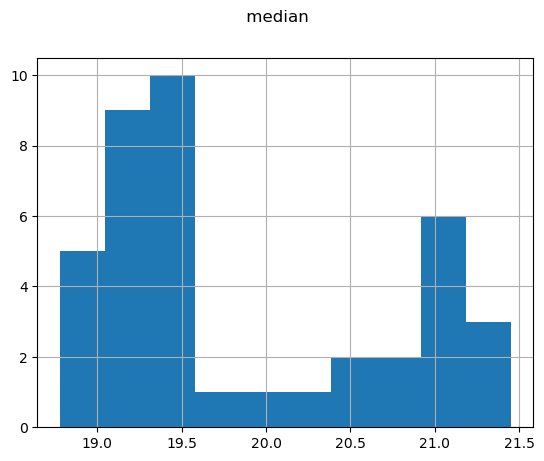

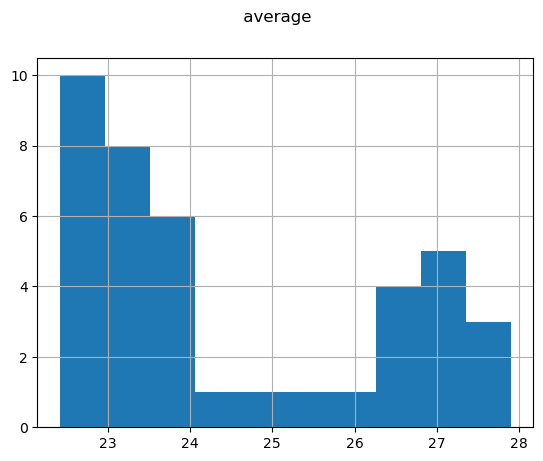

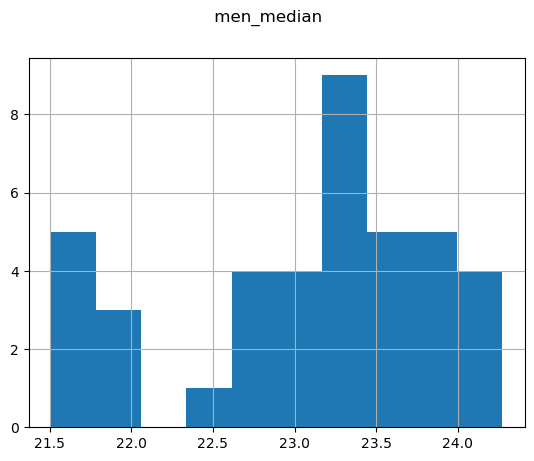

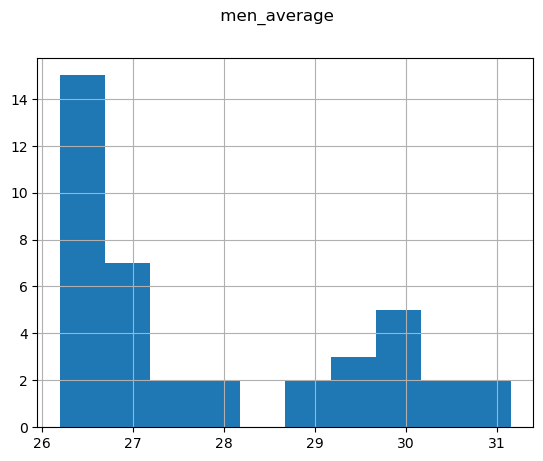

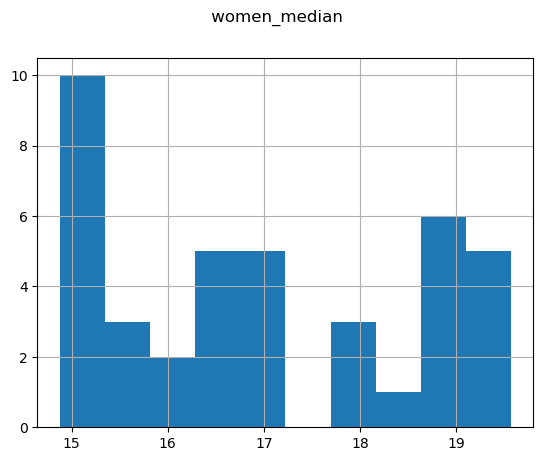

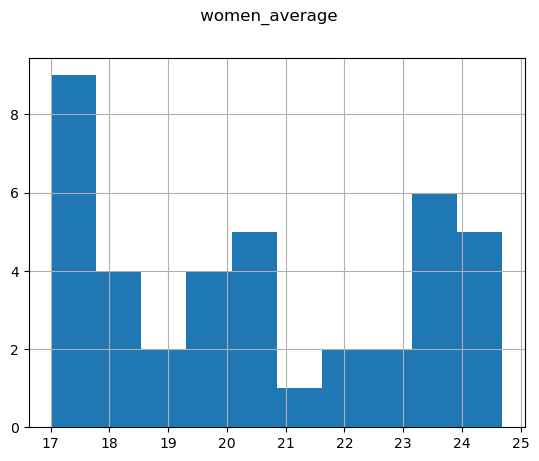

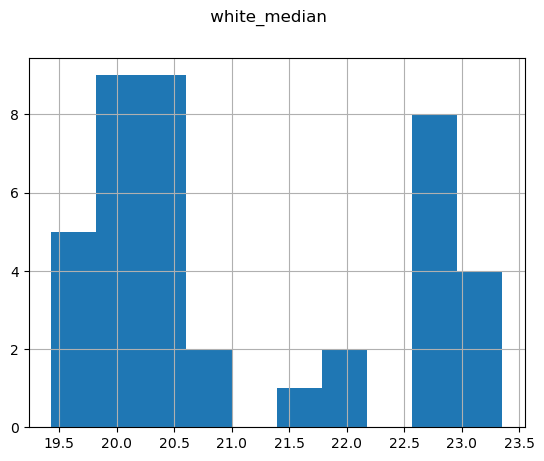

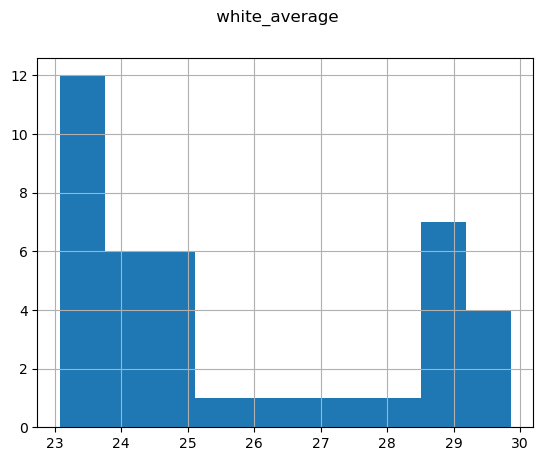

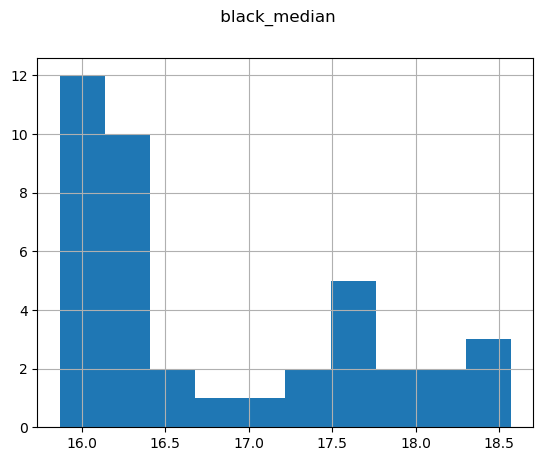

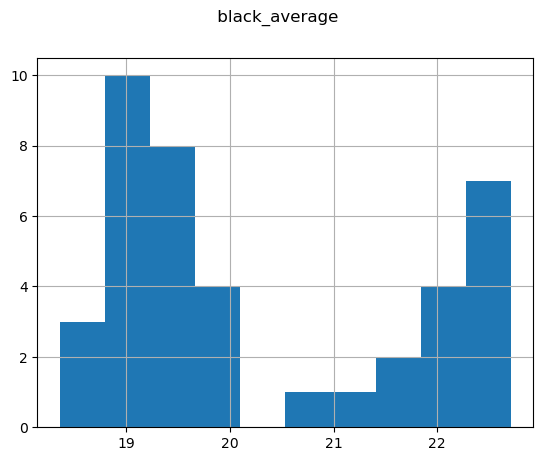

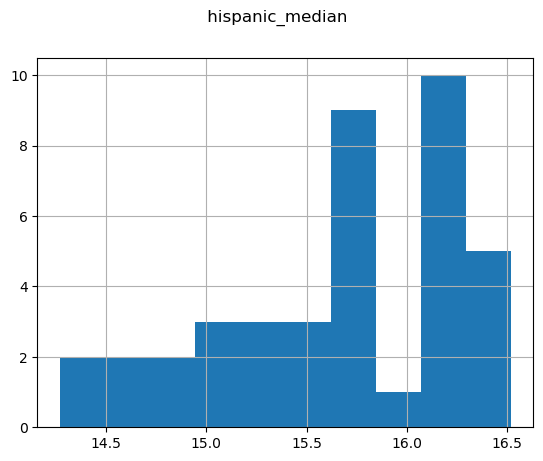

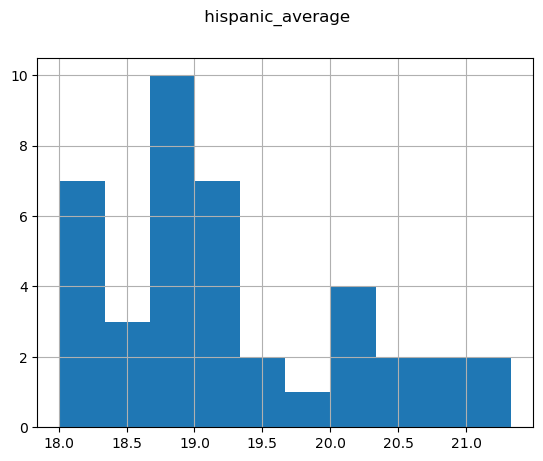

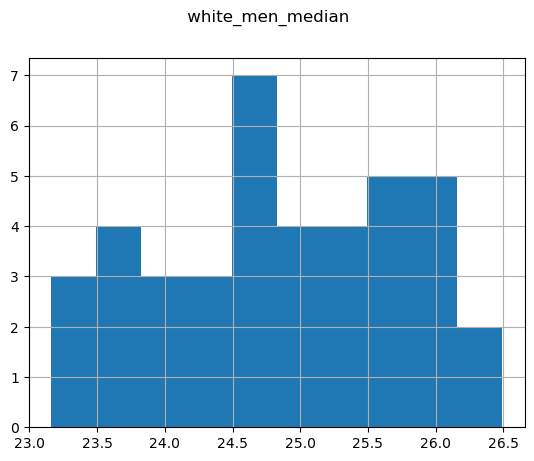

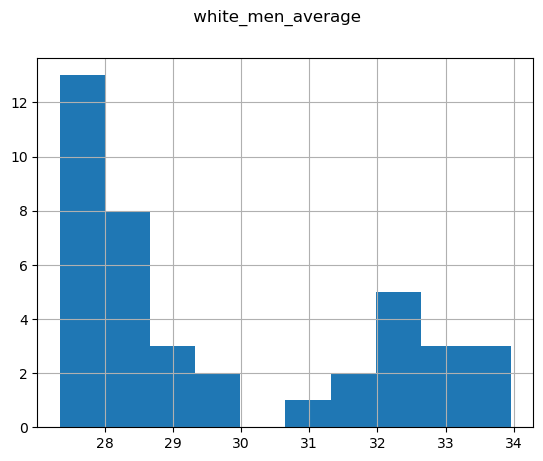

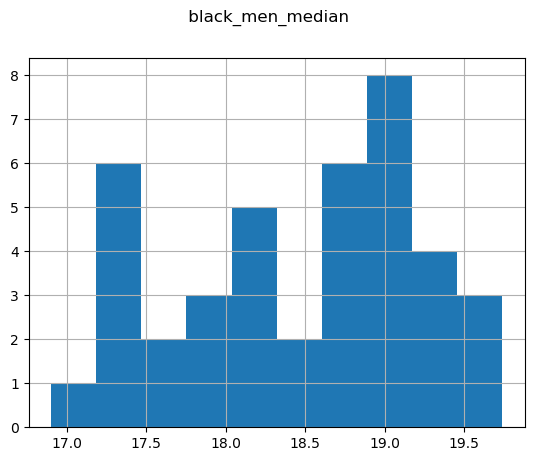

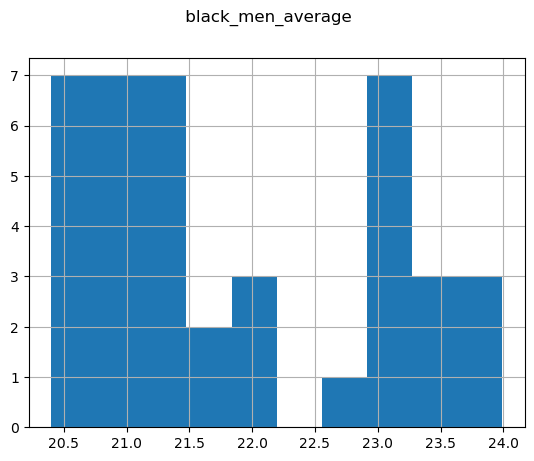

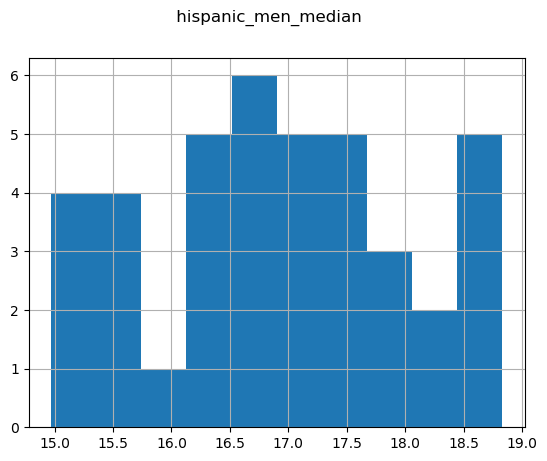

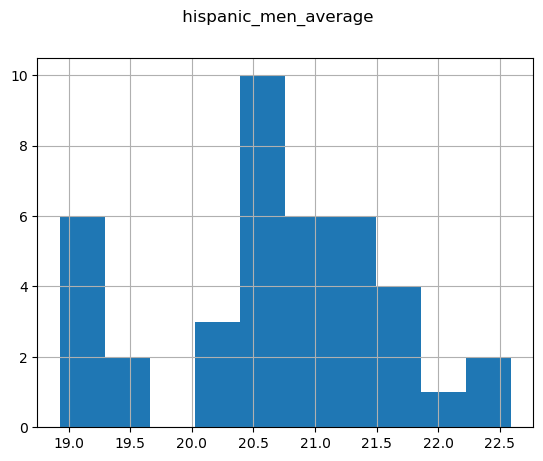

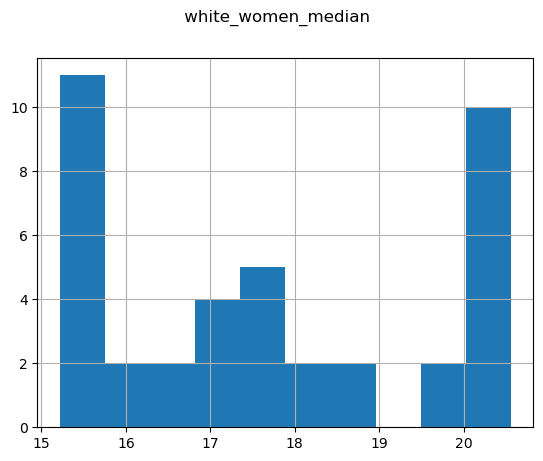

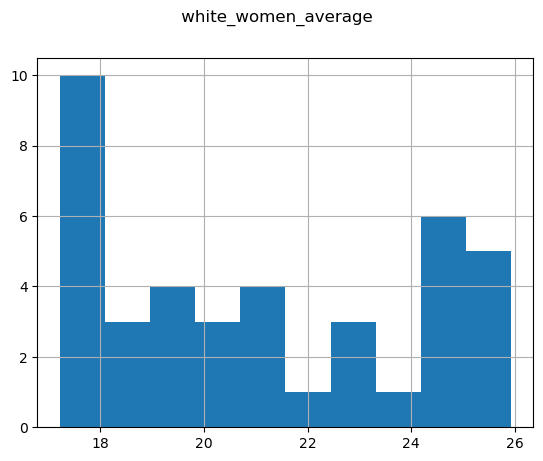

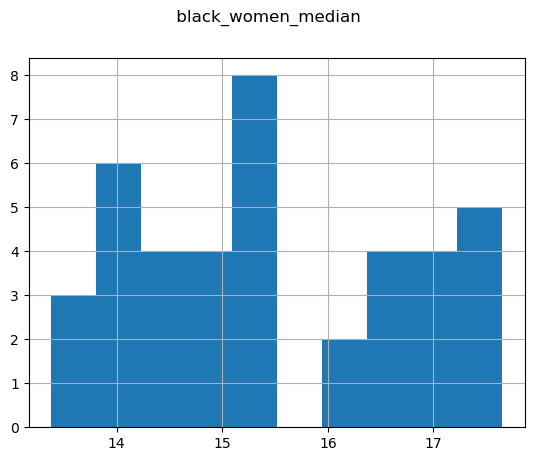

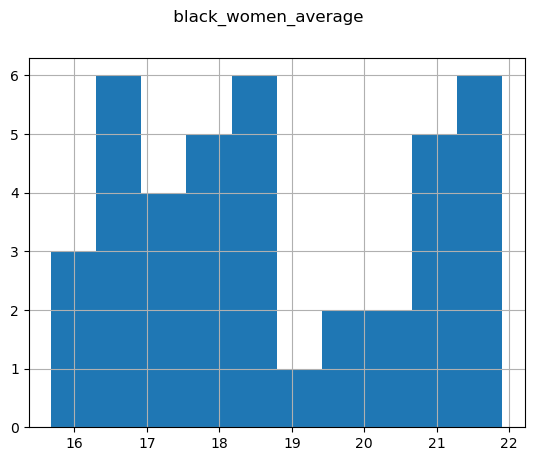

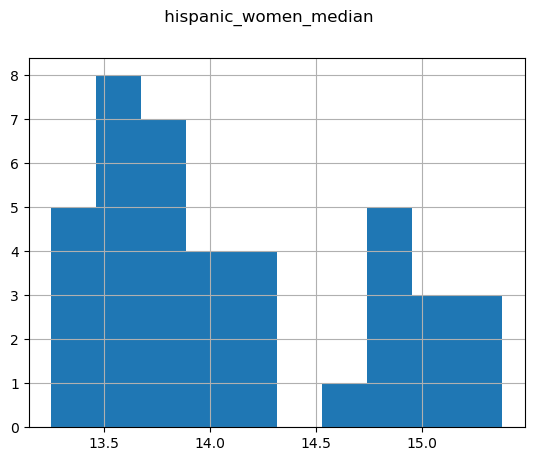

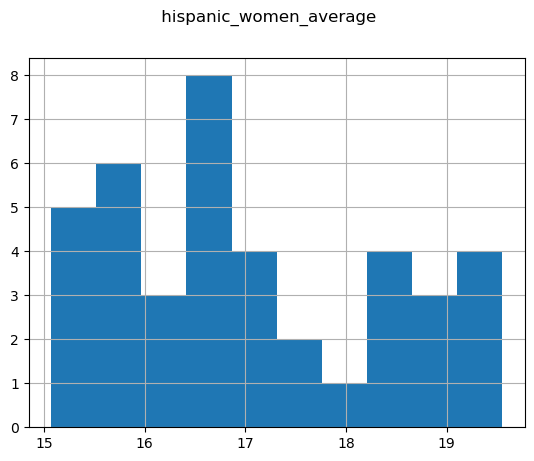

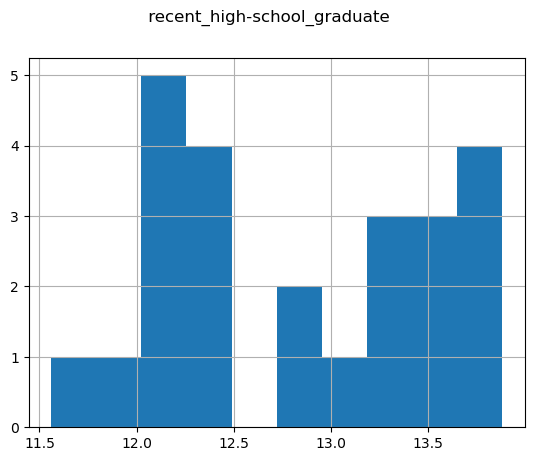

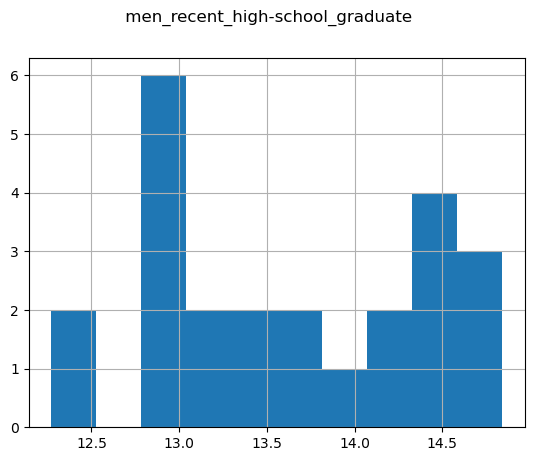

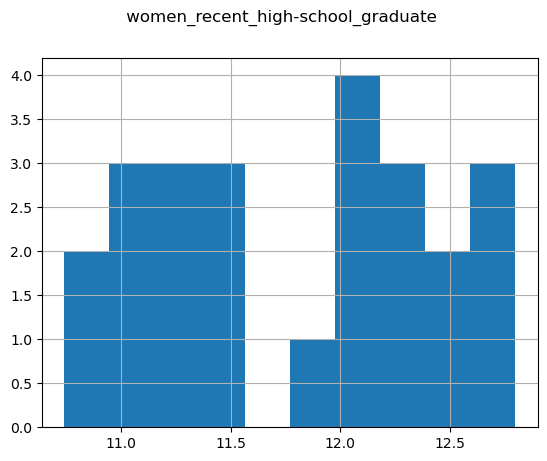

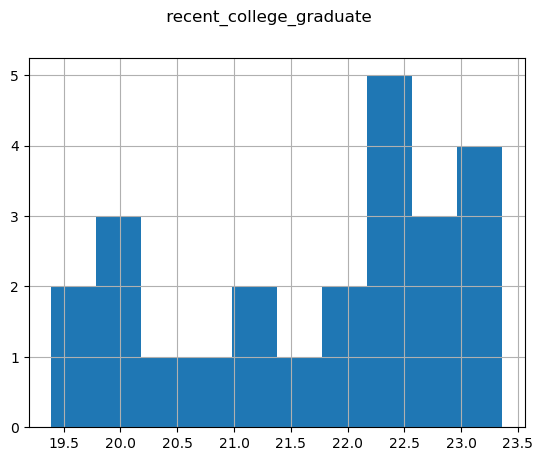

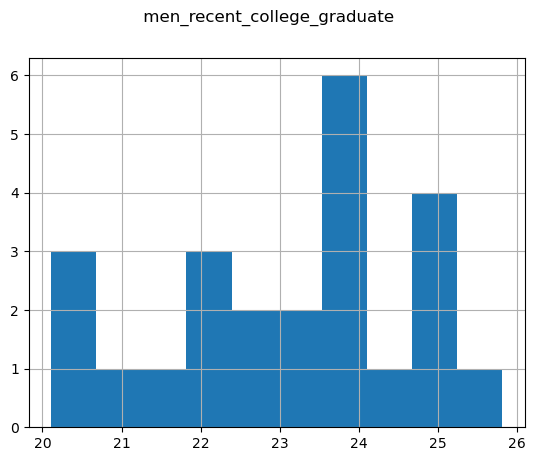

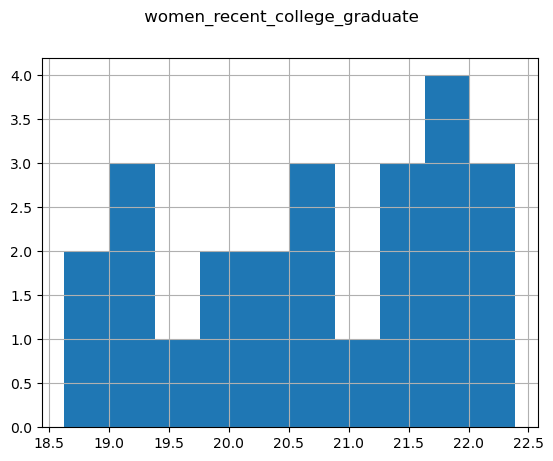

In [7]:
i = 1
cols = wage_data.columns[i:]
for  df in group_train:
    plt.figure()
    df.hist()
    plt.suptitle(f" {cols[i - 1]} ")
    i += 1
    plt.show()
    plt.close()

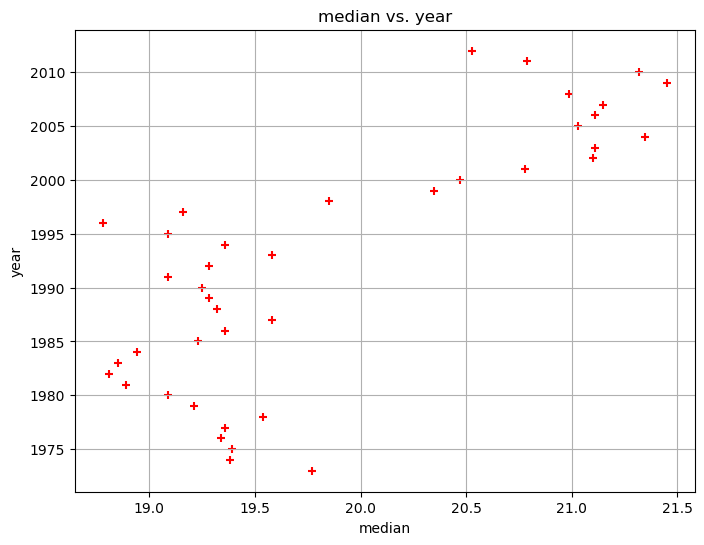

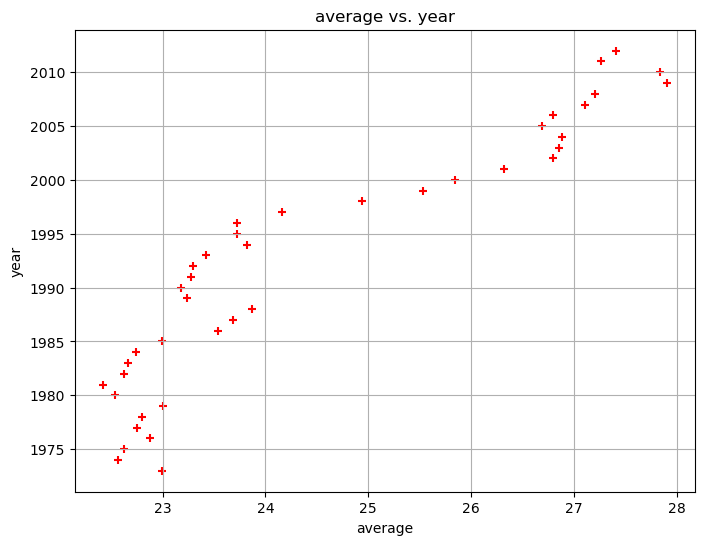

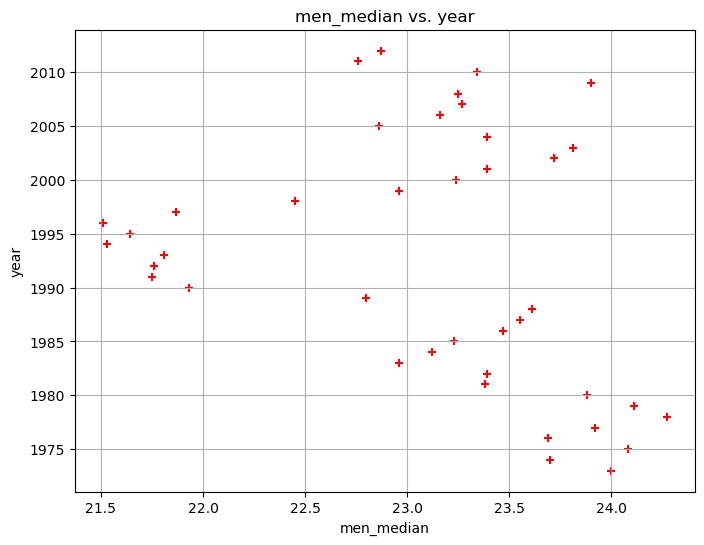

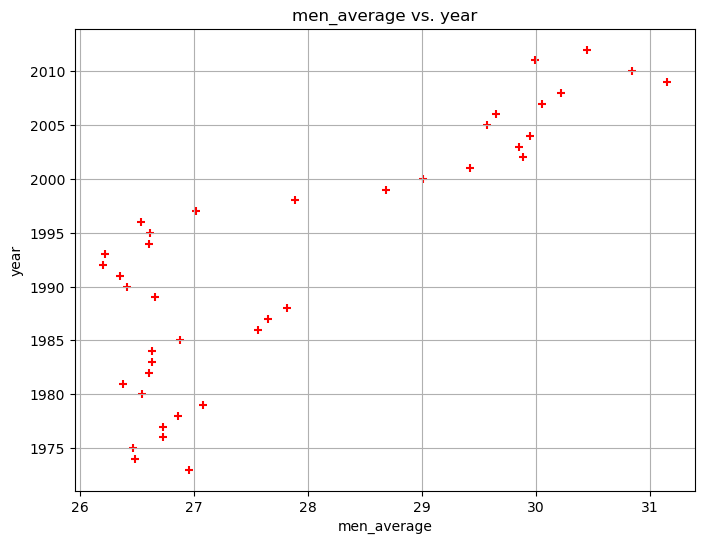

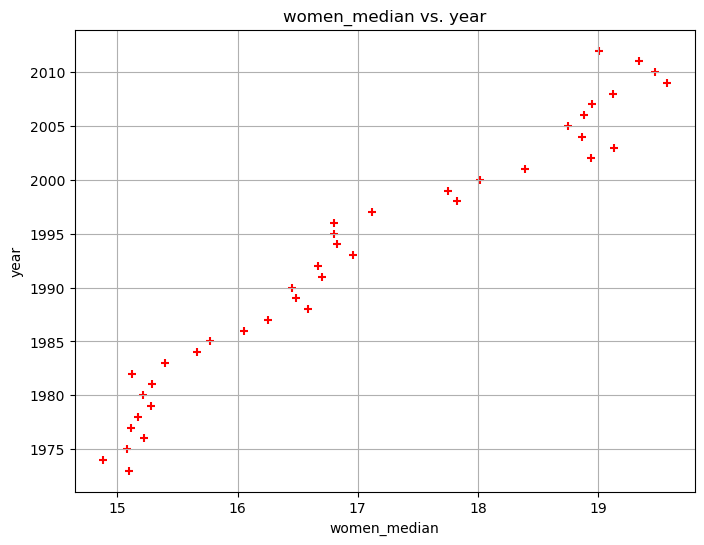

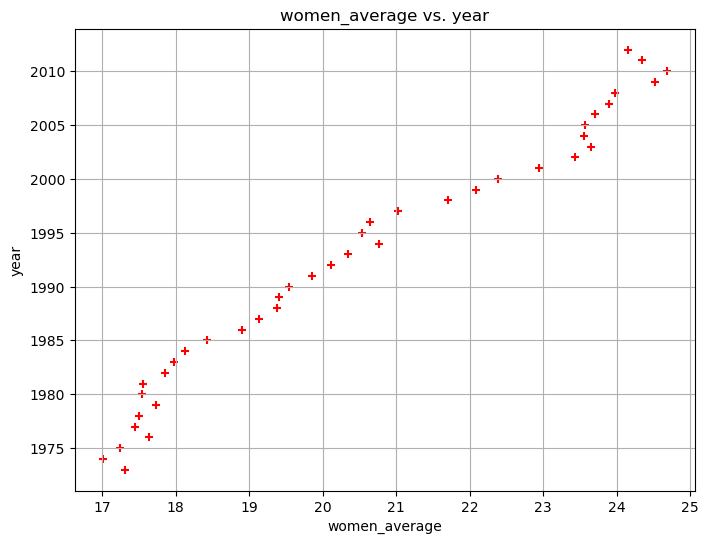

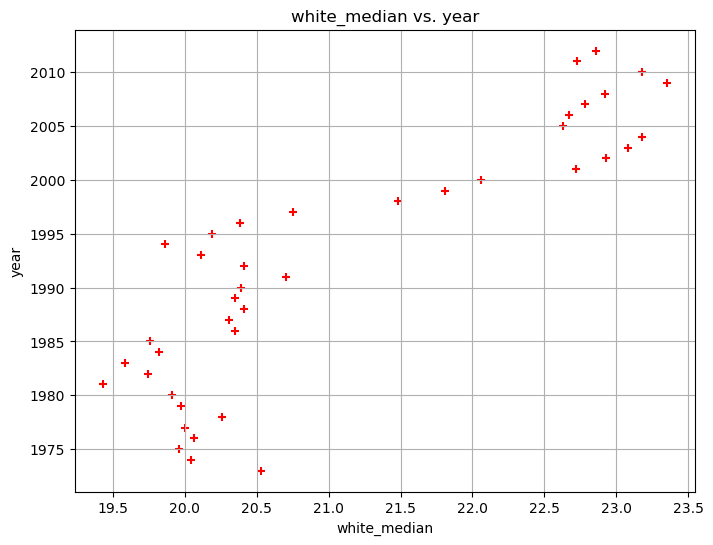

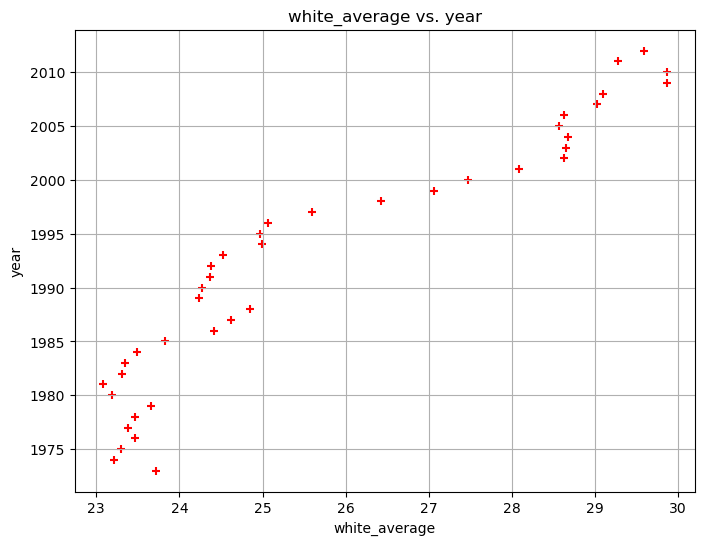

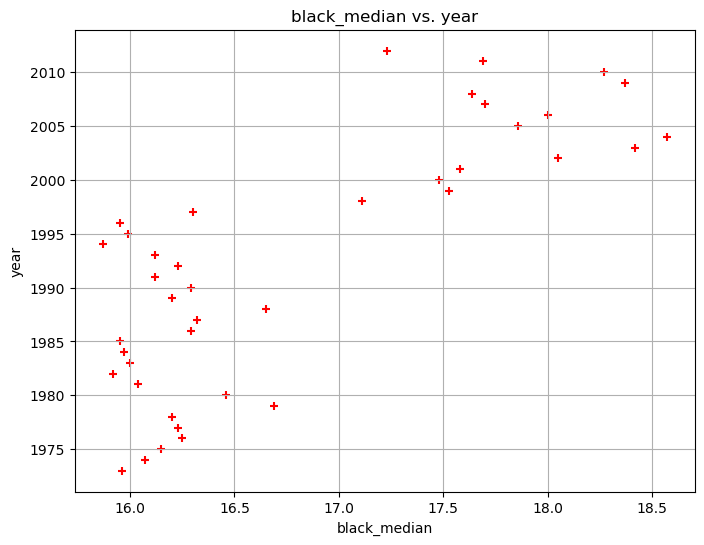

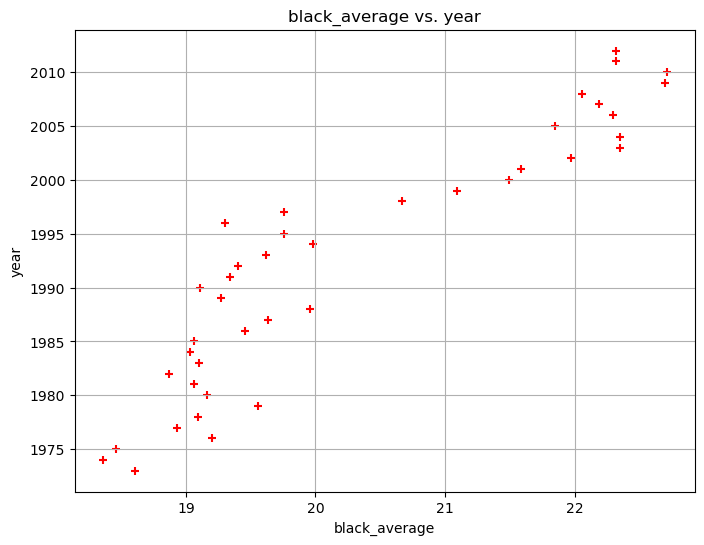

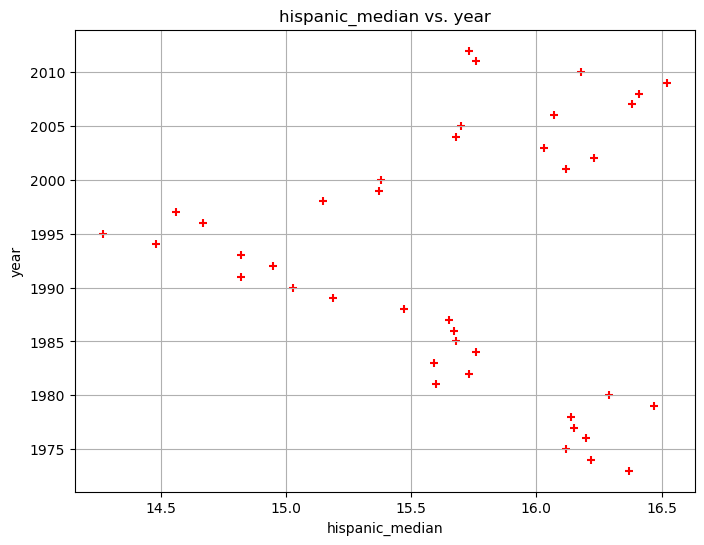

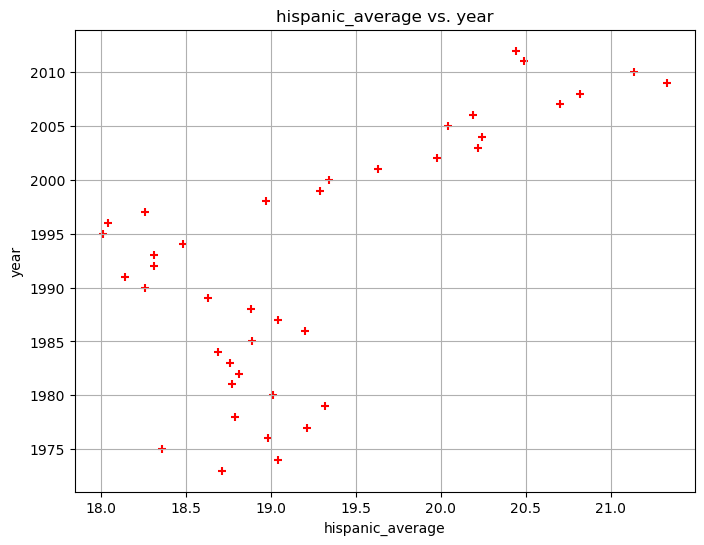

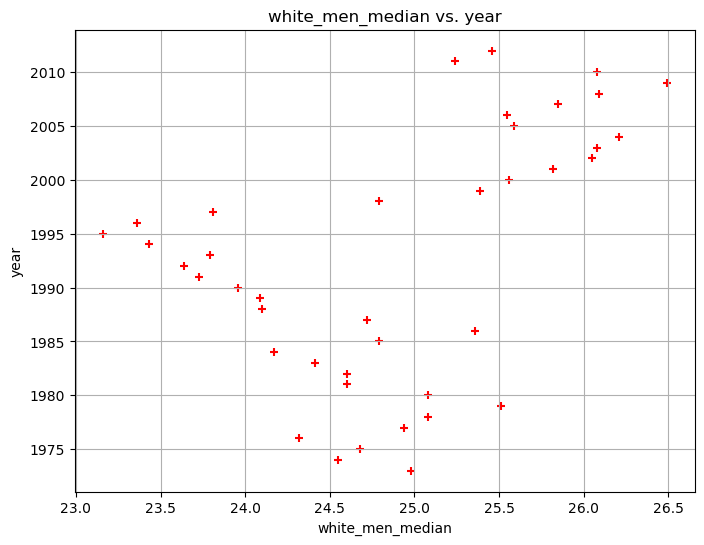

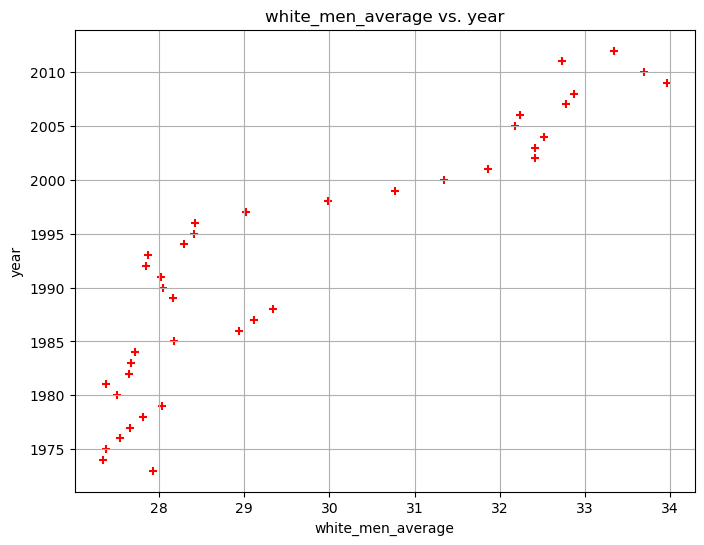

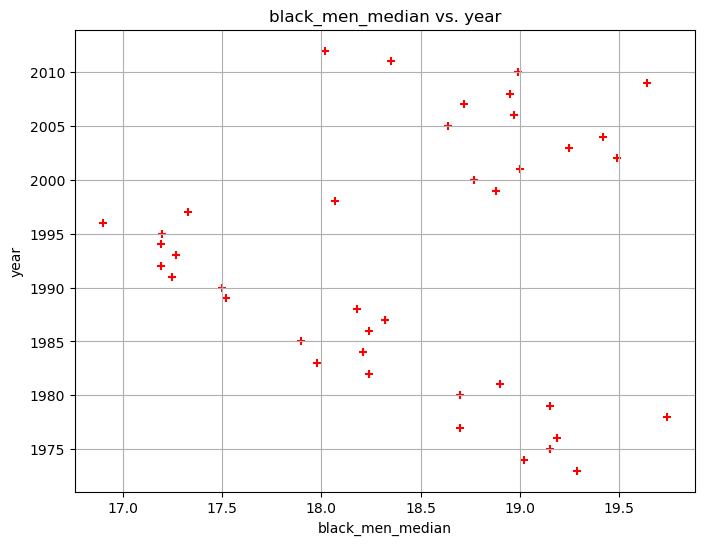

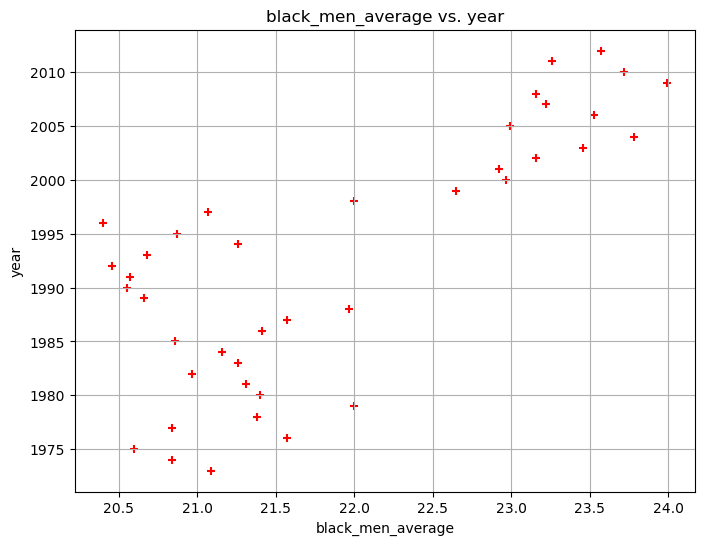

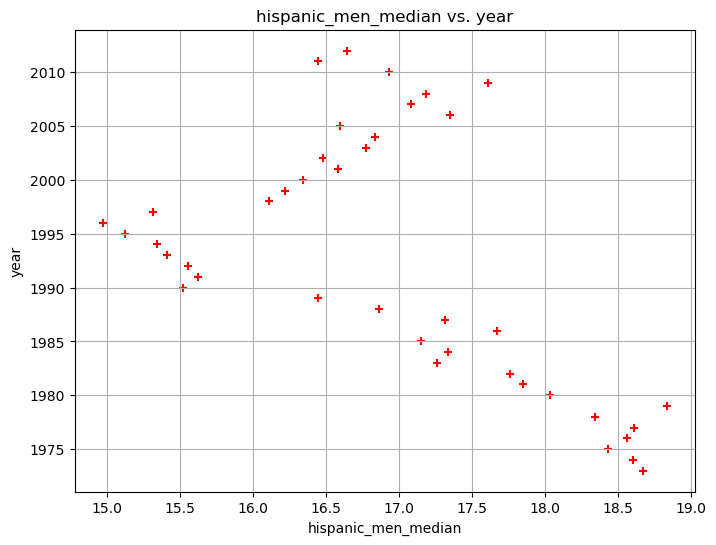

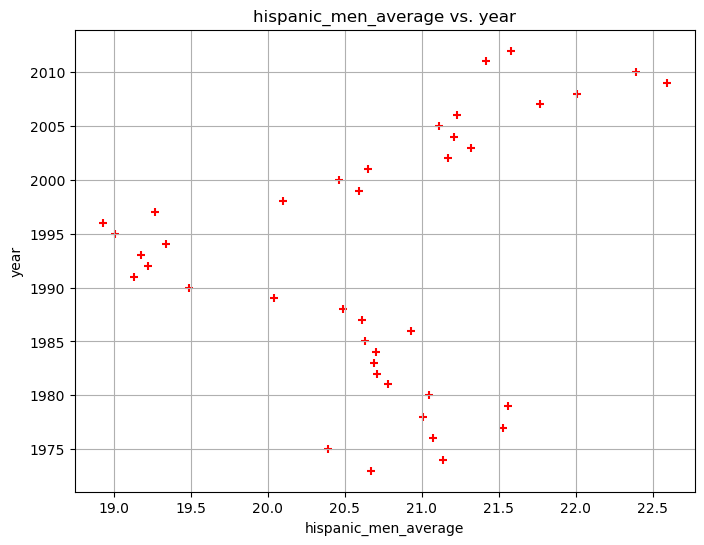

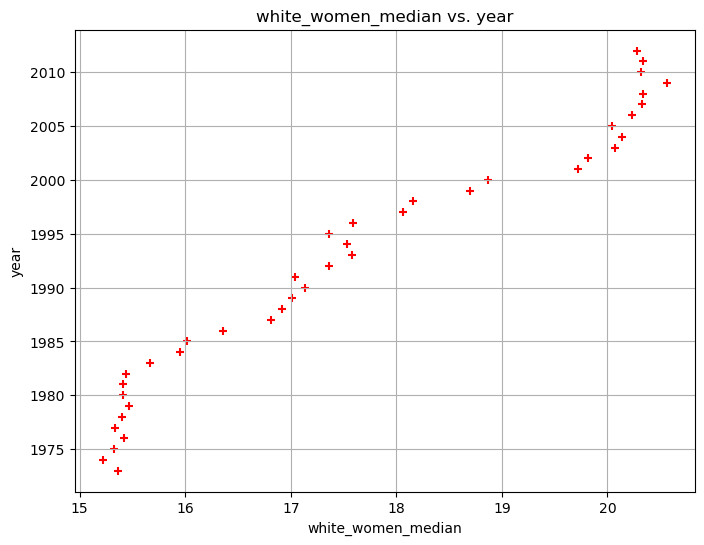

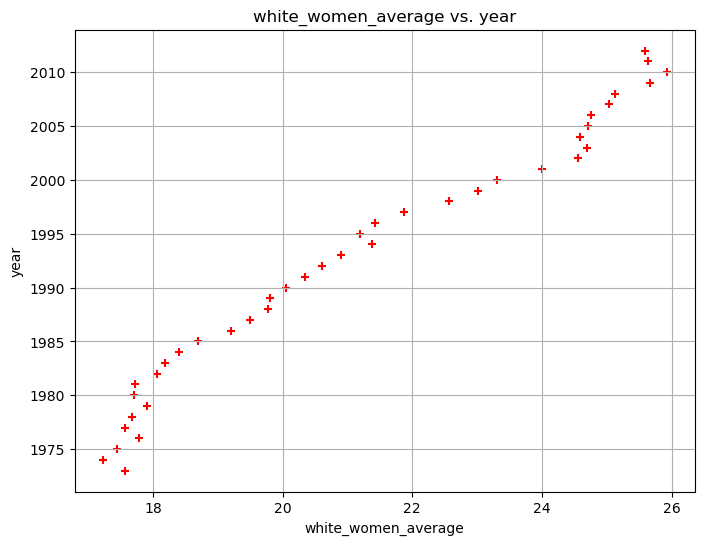

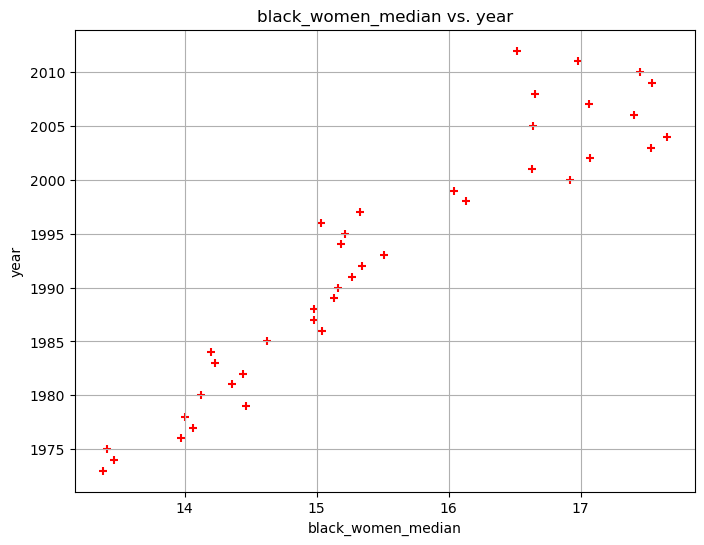

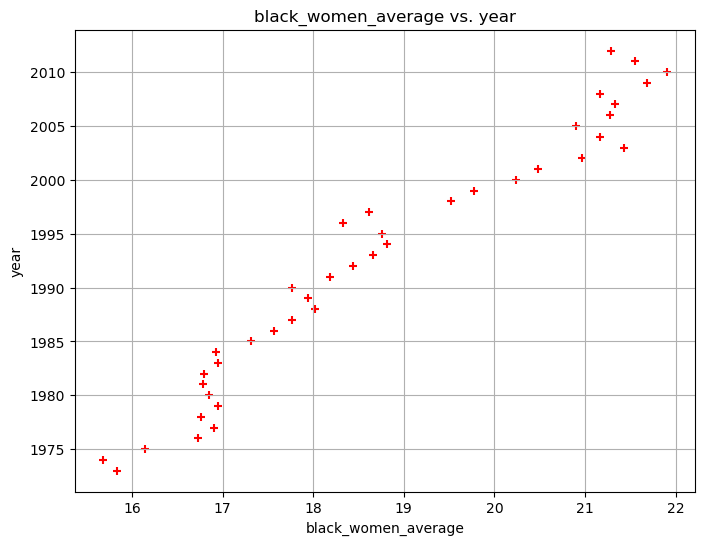

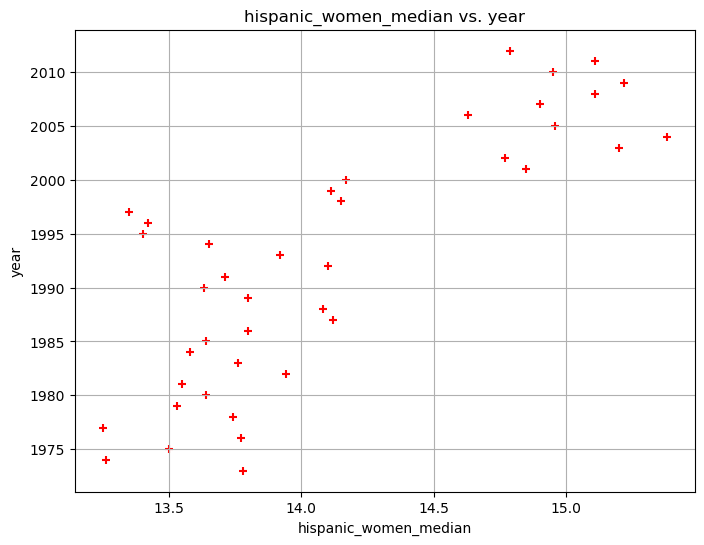

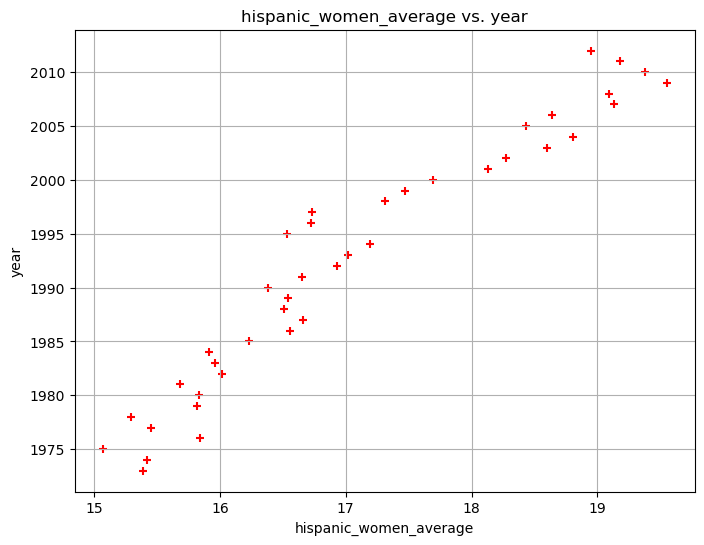

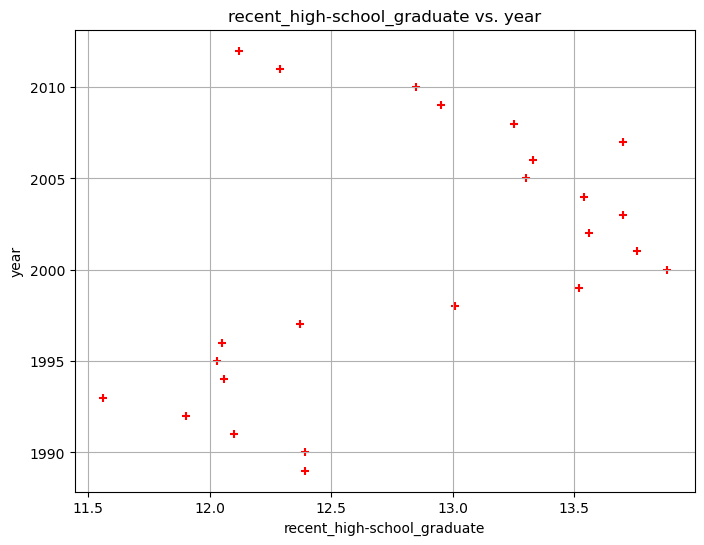

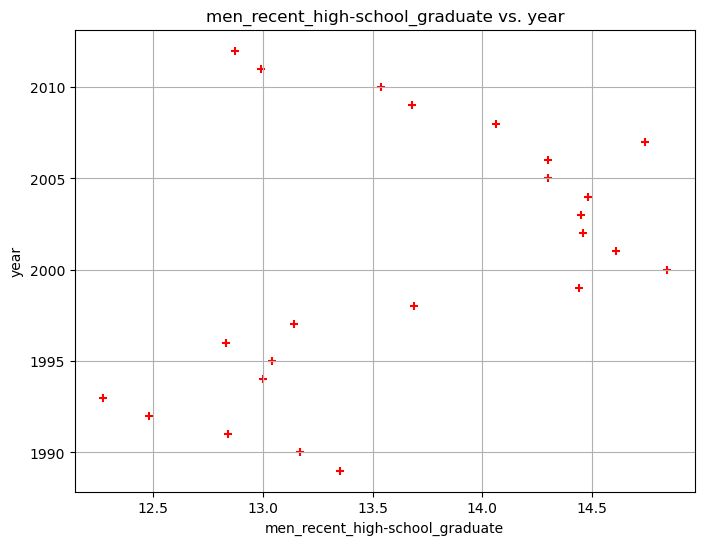

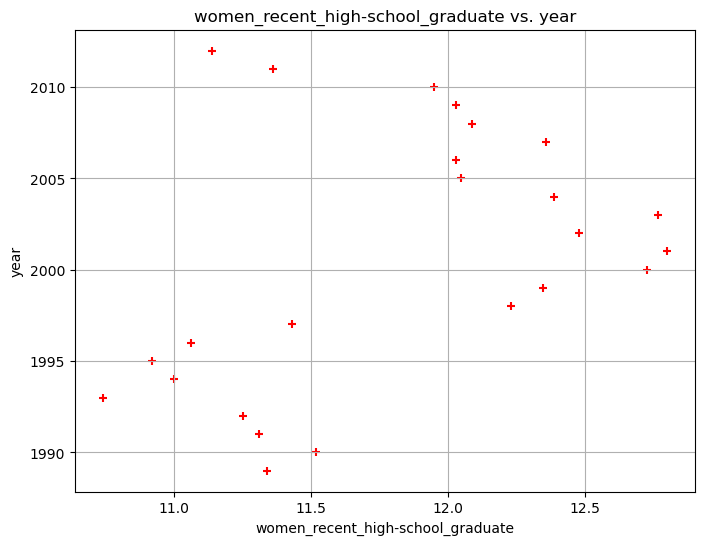

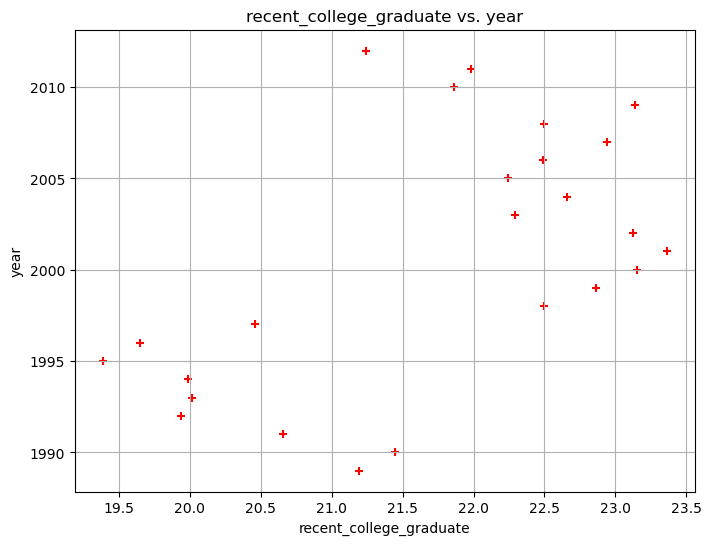

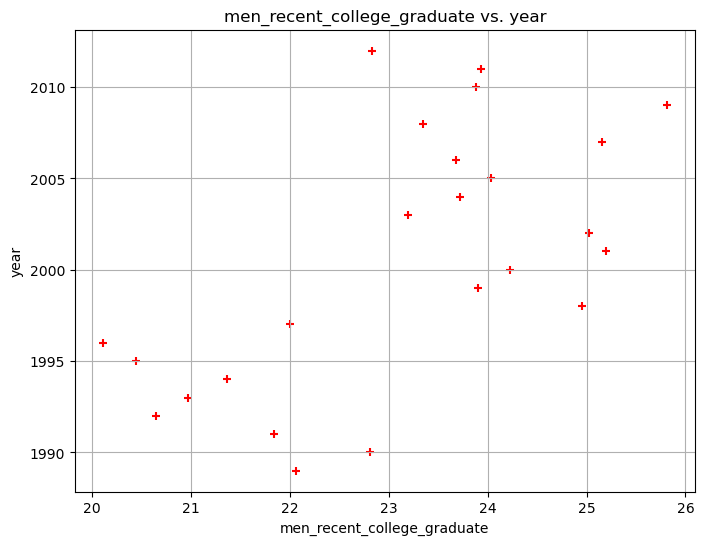

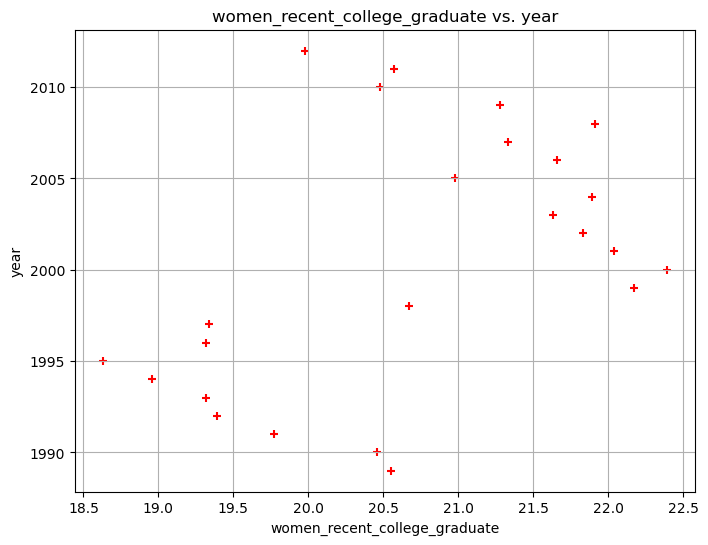

In [8]:
i = 1
for df in group_train:
    a = wage_data.columns[i]
    b = wage_data.columns[0]
    plt.figure(figsize=(8,6))
    aligned = pd.concat([df, year_train], axis = 1, keys = [a, b]).dropna()
    plt.scatter(aligned[a], aligned[b], color='red', marker='+')
    plt.title(a + " vs. " + b)
    plt.grid(True)
    plt.xlabel(a)
    plt.ylabel(b)
    plt.show()
    plt.close()
    i+=1

##  Models

We will begin implementing both the linear regression and ARIMA models.

In [17]:
arima_df = wage_data[:]
arima_df["year"] = pd.to_datetime(arima_df["year"], format="%Y")
arima_df = arima_df.sort_values("year")
arima_df = arima_df.set_index("year")
arima_df.index = arima_df.index.to_period('Y')
#print(arima_df)
forcast_results = []
metrics = []

In [45]:
#for group in arima_df.columns:
    #y= arima_df[group].interpolate(method="linear", limit_direction="both")
    #print(group)
    #y_train = y[:-split]
    #y_test = y.tail(split)
    #with warnings.catch_warnings():
        #forcaster = AutoARIMA(sp =1, suppress_warnings=True)
        #forcaster.fit(y_train)
        #original_range = list(range(1, len(y_test) + 1))
        #y_pred_test = forcaster.predict(fh=original_range)
        #error = numpy.sqrt(mean_absolute_error(y_test, y_pred_test))
        #error = mean_absolute_error(y_test, y_pred_test)
        #metrics.append({"Series": group, "Error": error})

        #forcast_results.append(y_pred_test)
        #Plot actual vs predicted
        #plt.figure(figsize=(8,4))
        #y.plot(label="Full series")
        #y_test.plot(label="Test set", style="--")
        #y_pred_test.plot(label="Forecast", style="--")
        #plt.title(f"Forecast for {group} (RMSE={error:.2f})")
        #plt.legend()
        #plt.show()
        #plt.close()
        #print(y_pred_test)
        #print(f"error: {error}")
    #print()
    #print()
    #print(y_test)
    #print(temp_df)

In [42]:
from statsmodels.tsa.api import VAR
df_filled = arima_df.interpolate(method="linear", limit_direction="both")
df_diff = df_filled.diff().dropna()
#print(df_diff)
train = df_diff[:-split]
test = df_diff.tail(split)
model = VAR(train)
results = model.fit(maxlags=1)
lag_order = results.k_ar
forecast_input = train.values[-lag_order:]
forecast = results.forecast(y=forecast_input, steps=len(test))
forecast_df = pd.DataFrame(forecast, index=test.index, columns=df_diff.columns)
df_diff.index = df_diff.index.to_timestamp()
forecast_df.index = forecast_df.index.to_timestamp()
#print(test)

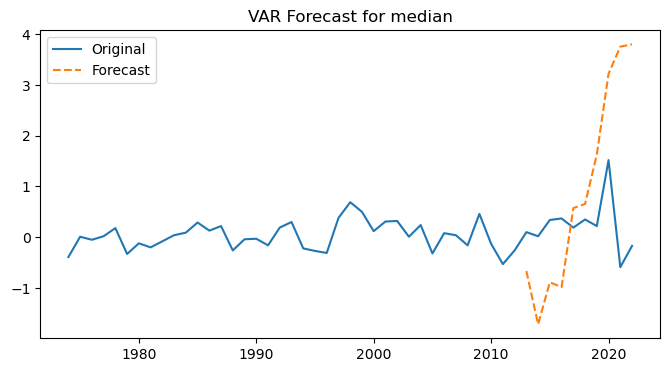

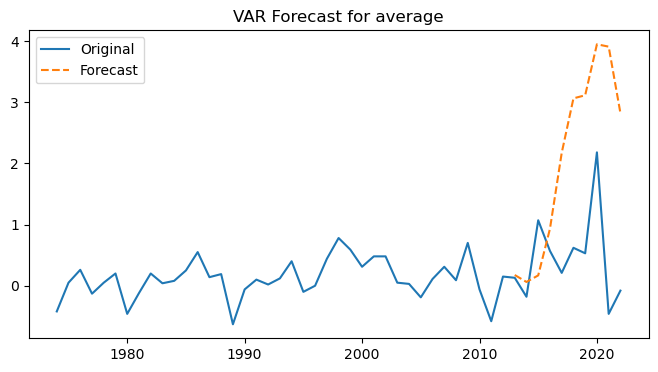

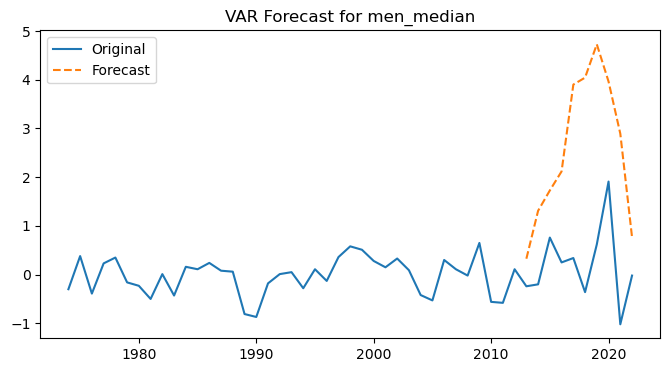

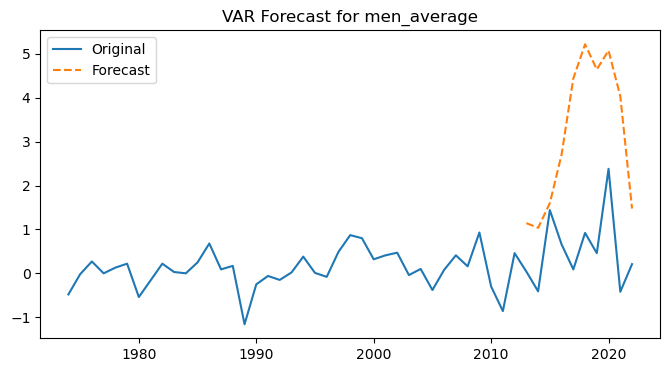

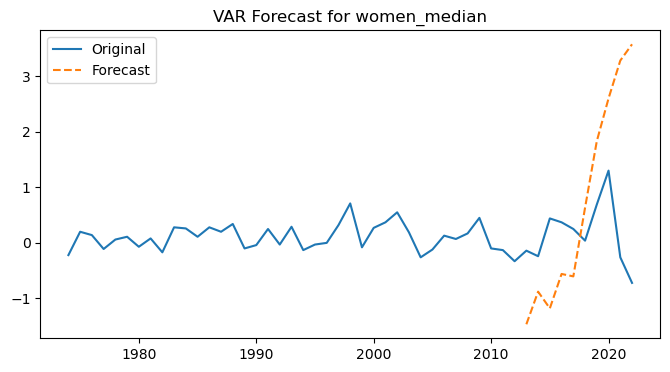

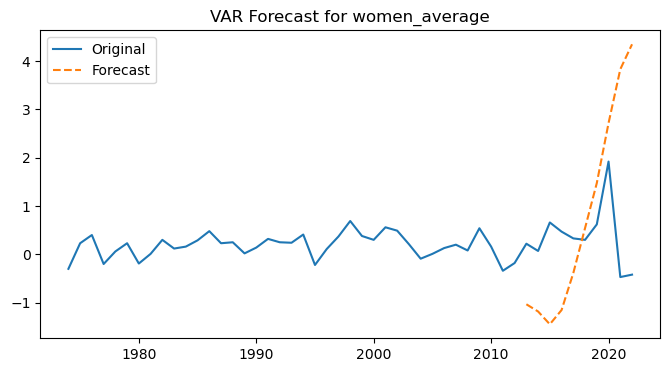

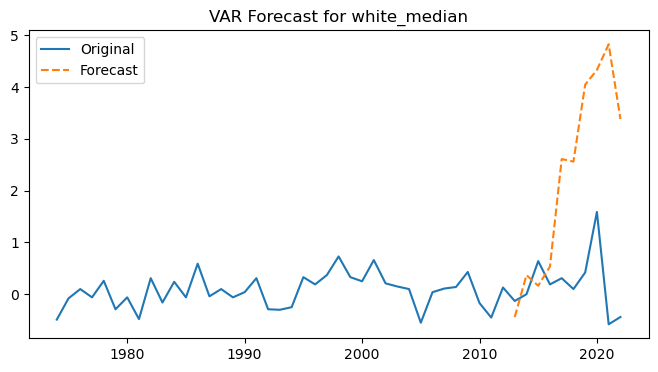

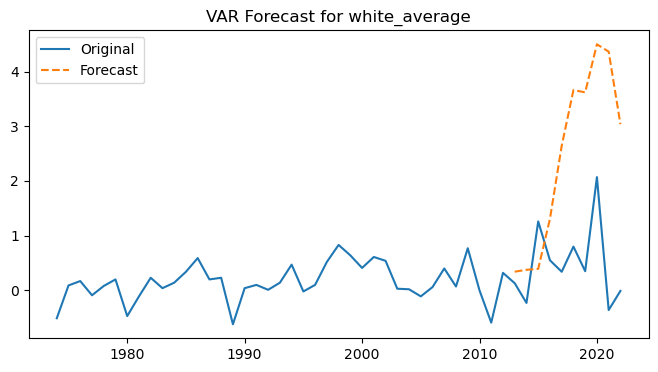

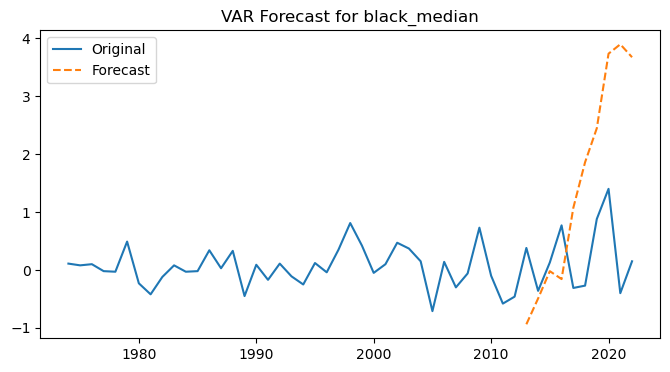

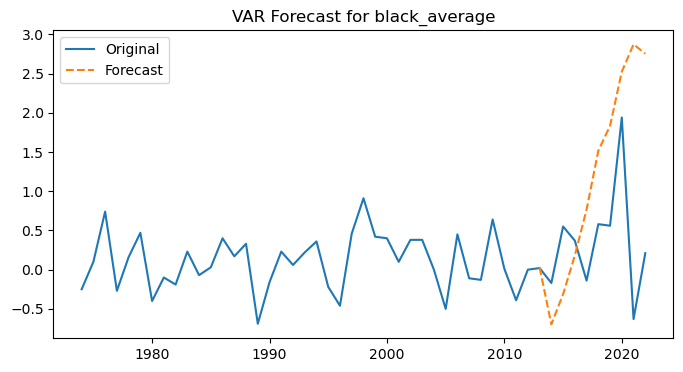

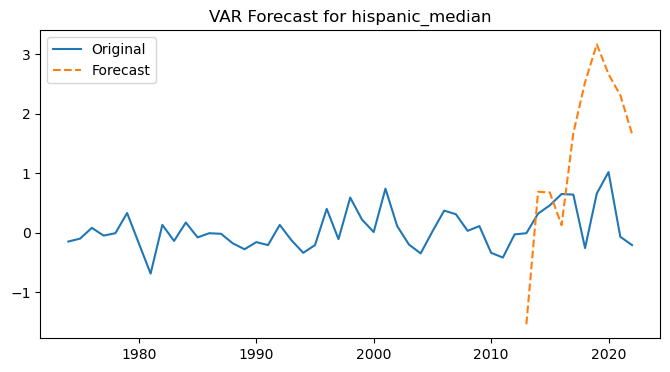

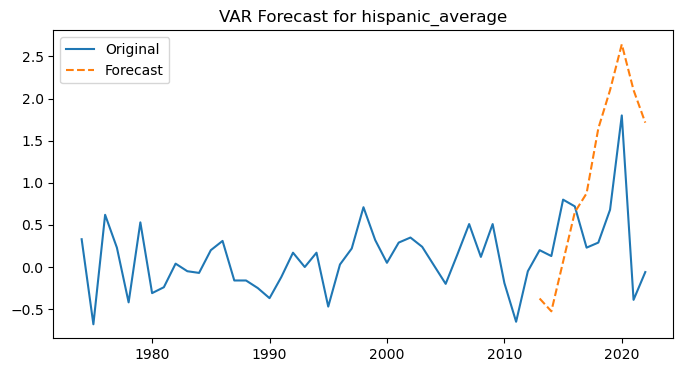

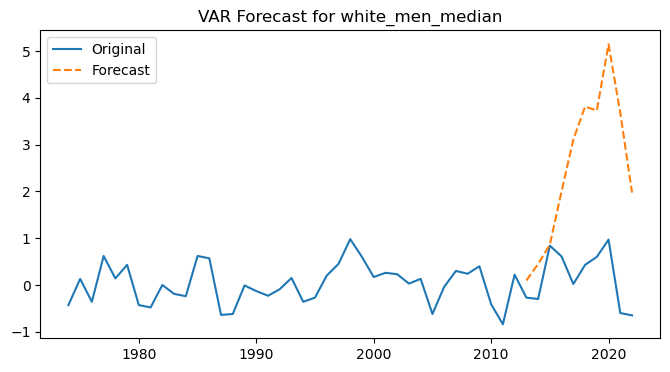

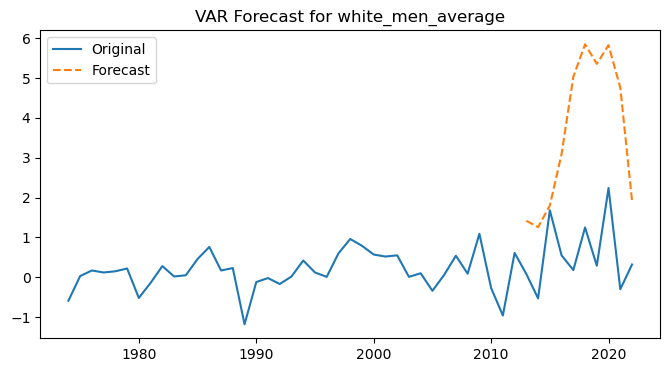

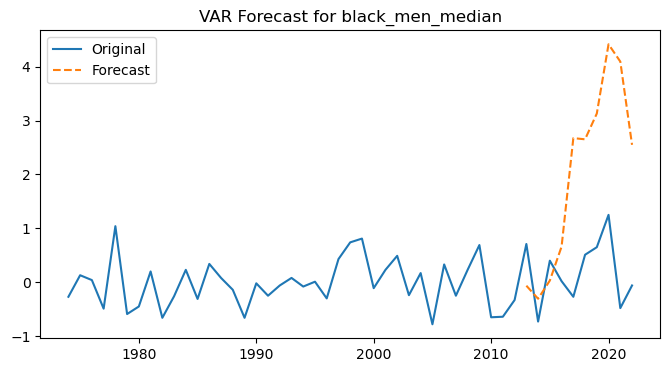

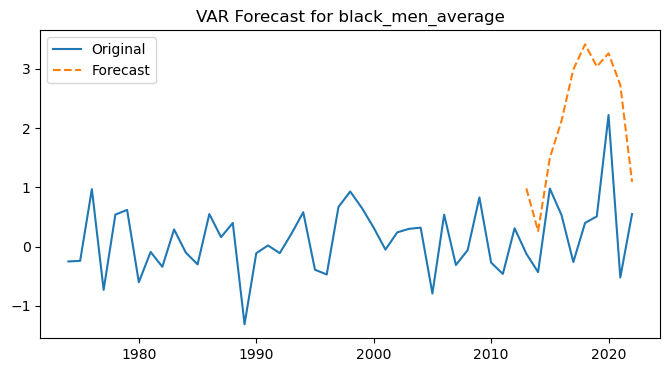

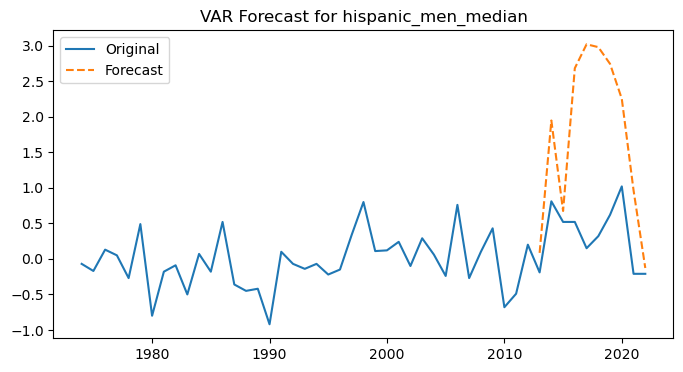

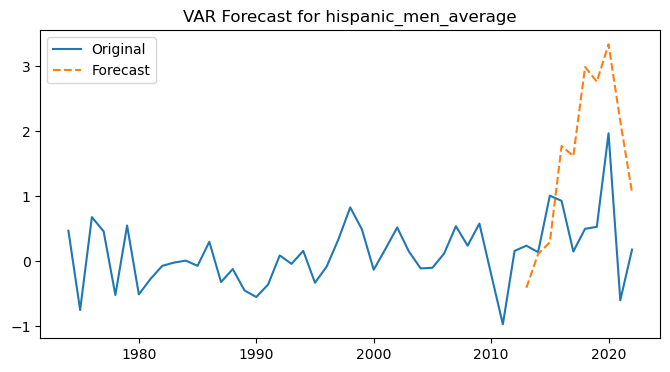

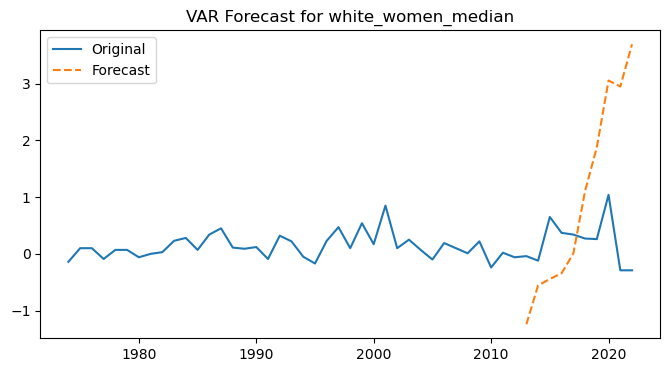

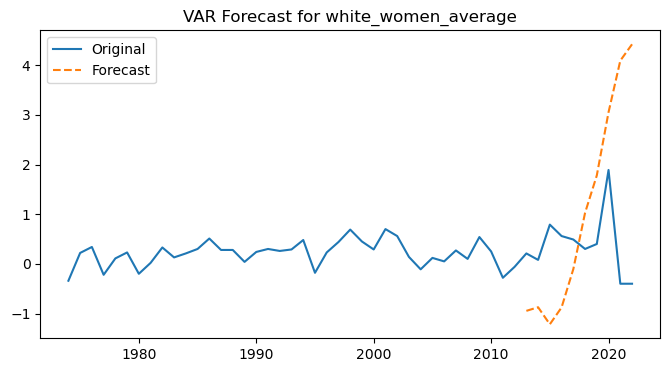

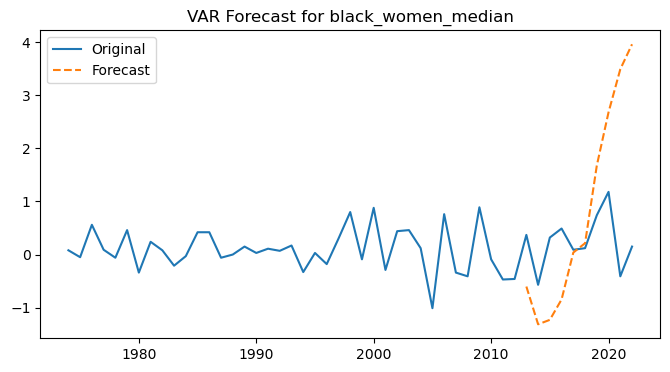

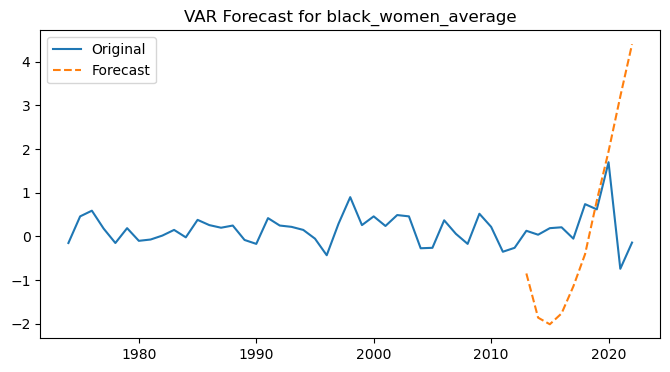

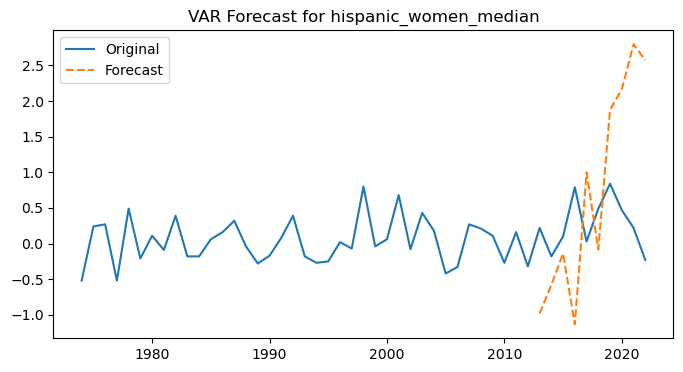

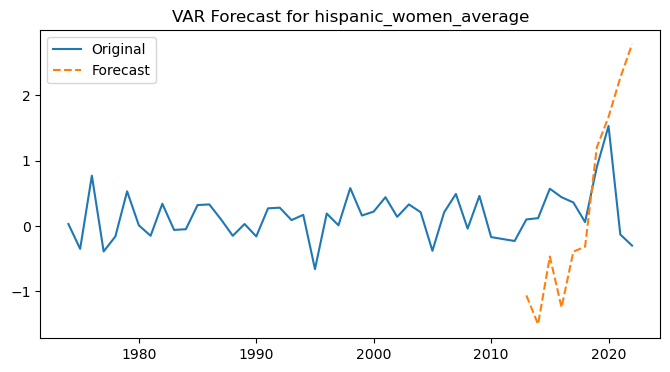

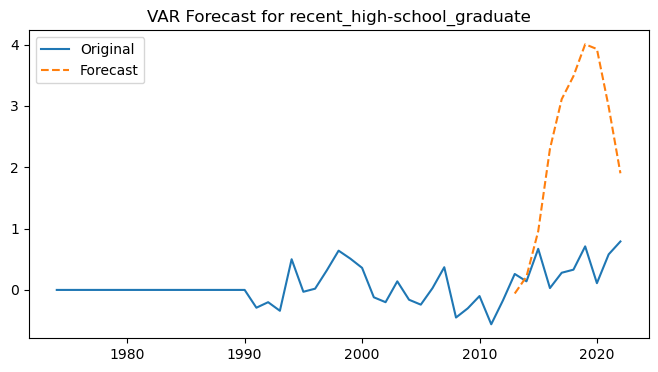

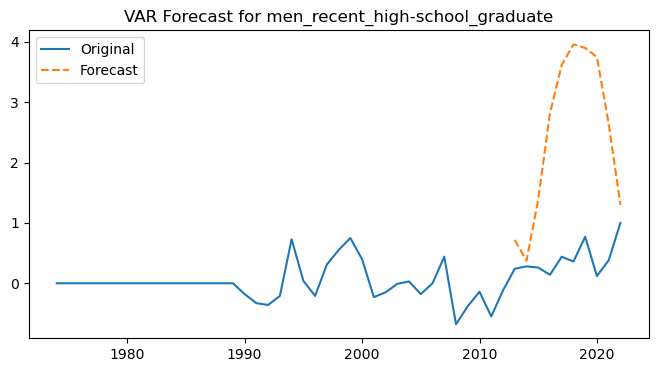

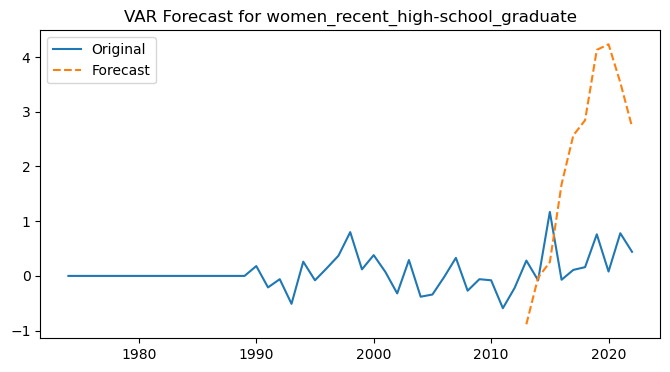

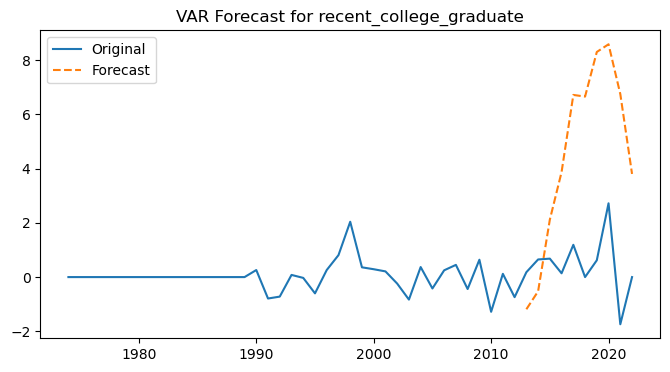

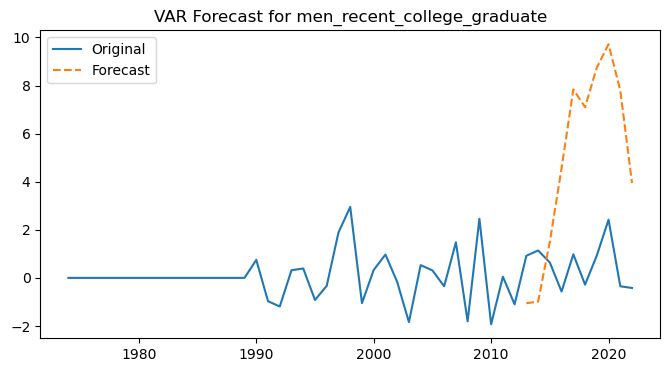

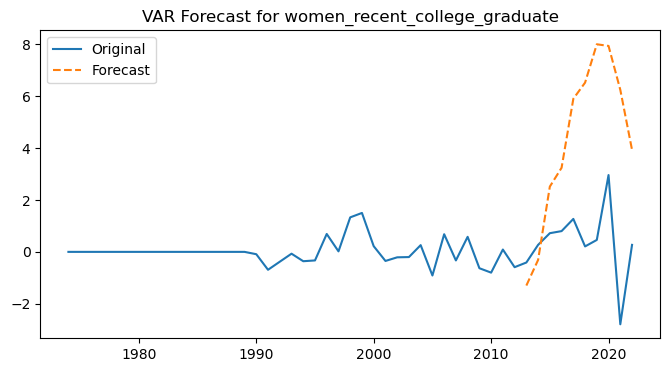

In [43]:
for col in df_diff.columns:
    plt.figure(figsize=(8,4))
    plt.plot(df_diff.index, df_diff[col], label="Original")
    plt.plot(forecast_df.index, forecast_df[col], label="Forecast", linestyle="--")
    plt.title(f"VAR Forecast for {col}")
    plt.legend()
    plt.show()
    plt.close()

In [48]:
overall_rmse = numpy.sqrt(mean_squared_error(test.values, forecast_df.values))
print(f"Overall RMSE: {overall_rmse:.4f}")

Overall RMSE: 2.7286


##  Evaluation Metrics

We will now give the RMSE of our models

In [49]:
overall_rmse = numpy.sqrt(mean_squared_error(test.values, forecast_df.values))
print(f"Overall RMSE for ARIMA VAR: {overall_rmse:.4f}")

Overall RMSE for ARIMA VAR: 2.7286


In [51]:
rmse_dict = {}

for col in test.columns:
    rmse = numpy.sqrt(mean_squared_error(test[col], forecast_df[col]))
    rmse_dict[col] = rmse

print("RMSE ARIMA VAR per column:")
for col, rmse in rmse_dict.items():
    print(f"{col}: {rmse:.4f}")

RMSE ARIMA VAR per column:
median: 2.1611
average: 2.1933
men_median: 2.7593
men_average: 3.0178
women_median: 2.0169
women_average: 2.3104
white_median: 2.7650
white_average: 2.5182
black_median: 2.1864
black_average: 1.5314
hispanic_median: 1.7292
hispanic_average: 1.2508
white_men_median: 2.7572
white_men_average: 3.5034
black_men_median: 2.4182
black_men_average: 2.0606
hispanic_men_median: 1.6970
hispanic_men_average: 1.5887
white_women_median: 1.9278
white_women_average: 2.3643
black_women_median: 1.9631
black_women_average: 2.2822
hispanic_women_median: 1.5828
hispanic_women_average: 1.5481
recent_high-school_graduate: 2.3607
men_recent_high-school_graduate: 2.4479
women_recent_high-school_graduate: 2.4476
recent_college_graduate: 5.2342
men_recent_college_graduate: 5.8030
women_recent_college_graduate: 4.9817
